In [1]:
###### INFORM .py files necessary for processing aircraft data
import inform_utils as inform # INFORM python module inform_utils.py
import process_data_products_utils as pdp # INFORM python module, process_data_products
#######

import xarray as xr
from datetime import time
import warnings
warnings.filterwarnings('ignore')
from tqdm.notebook import tqdm, trange
import dask
from dask_jobqueue import PBSCluster
from dask.distributed import Client
import pandas as pd

# Individual flight analysis

### 1. Load aircraft data into pandas dataframe

In [5]:
# Location of aircraft data files (.nc files)
#==============================================
campaign = 'SOCRATES'
#==============================================

# Assign Flight number
#===========================================
flight_number = 1 # Select Research Flight
#===========================================

df = inform.load_flight_data(campaign,flight_number-1) # 0 is Index of research flight

### 2. Block flight maneuvers 

In [6]:
blocks = pdp.VAP_process_flight_data(df,flight_number-1)

### optional, plot flight profile with blocked flight maneuvers

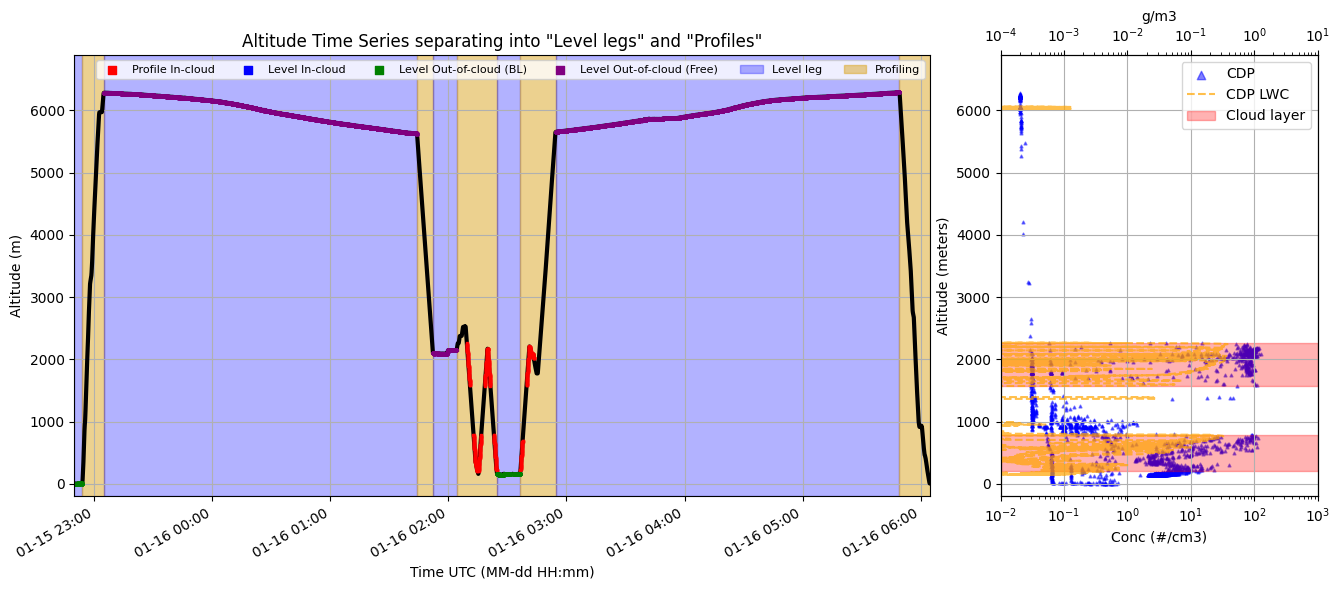

In [7]:
dict = pdp.assign_flight_type(df)
# Function to plot blocked flight manevuer altitude time series. Use to verify correct blocking methonds
pdp.plot_block_ts(dict,flight_number)

### 3. Collocate ERA5 data
* #### Uses ERA5 Reanalysis (0.25 Degree Latitude-Longitude Grid)
* #### d633000 | DOI: 10.5065/BH6N-5N20

In [ ]:
# Select ERA5 dataset for Aircraft Campaign Time Frame
#=============================================================
ds = pdp.select_ERA5_4flight(df) # Finds date/times from aircraft and will select correct ERA5 data for the timeframe of flight
# Collocate ERA5 data and calculate environmental controlling factors
fblks_coll = pdp.collocate_ERA5_dat(ds, blocks) 

### 4. Composite aircraft data into cloud regimes 
* #### Here it will only compsoite into stratocumulus and open-cell cloud regimes - future versions will have additional cloud regimes/types

In [ ]:
# Select cloud regime type based on cloud controlling factors (CCFs)
fblks_cr = pdp.cloud_regime(fblks_coll)
# See documentation on CCFs used for compositng cloud regimes

### 5. Save data as netCDF

In [ ]:
rf_id = f"RF{flight_number:02d}"
write_RF_nc(fblks_cr, rf_id)

# Process all flights
* #### Here you simply select which campaign you would like to process (SOCRATES or CSET) and this will loop through all flights and produce composited datasets saved in netCDF format
* #### Run cell below to utilize dask parallel computing to improve speed of producing composited netCDFs

### Create dask cluster for parallel computing for time efficiency

In [ ]:
cluster = PBSCluster(
    cores = 1,
    memory = '30GB',
    processes = 1,
    queue = 'casper',
    local_directory = '$TMPDIR',
    resource_spec = 'select=1:ncpus=1:mem=30GB',
    project='',
    walltime='00:30:00',
    interface='mgt')

# scale up
cluster.scale(12)

# change your urls to the dask dashboard so that you can see it
dask.config.set({'distributed.dashboard.link':'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'})

# Setup your client
client = Client(cluster)

In [3]:
cluster

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/patnaude/proxy/33413/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.18.205.13:36611,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/patnaude/proxy/33413/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [ ]:
campaign = 'CSET' # SOCRATES or CSET

if campaign == 'SOCRATES':
    dir = '/glade/work/patnaude/SOCRATES/aircraft_1hz/'
    ccn_dir = '/glade/work/patnaude/SOCRATES/CCN'
elif campaign  == 'CSET':
    dir = '/glade/work/patnaude/CSET/aircraft_1hz/'

flight_paths = inform.find_flight_fnames(dir)
all_fblks = {}

for i in tqdm(range(0,len(flight_paths))):
    df = inform.load_flight_data(dir,ccn_dir, i)

    
    if ('PLWC' in df.columns) and (campaign == 'SOCRATES'): # RF12 is the only fligth with this variable and it messes up the final product
        df = df.drop(columns=['PLWC'])
    blocks = pdp.VAP_process_flight_data(df, i)

    # Select ERA5 data
    ds = pdp.select_ERA5_4flight(df, campaign)
    rf_id = f"RF{i+1:02d}"
    print(rf_id)
          
    # Collocate ERA5 data and calculate environmental controlling factors
    fblks_coll = pdp.collocate_ERA5_dat(ds, blocks)
    # Select cloud regime type based on cloud controlling factors
    fblks_cr = pdp.cloud_regime(fblks_coll, campaign=campaign)
    # Write to NetCDF for this flight
    pdp.write_RF_nc(fblks_cr, rf_id, campaign)

    # Save to master dictionary
    # all_fblks[rf_id] = fblks_cr

In [4]:
CAMPAIGN_CFG = {
    "SOCRATES": {
        "air_1hz_dir": "/glade/work/patnaude/SOCRATES/aircraft_1hz",
        "air_25hz_dir": "/glade/work/patnaude/SOCRATES/aircraft_25hz",
        "ccn_dir":      "/glade/work/patnaude/SOCRATES/CCN",
    },
    "CSET": {
        "air_1hz_dir": "/glade/work/patnaude/CSET/aircraft_1hz",
        "air_25hz_dir": "/glade/work/patnaude/CSET/aircraft_25hz",  # if you have it; else omit
        "ccn_dir": None,
    },
}

campaign = "SOCRATES"
flight_paths = inform.find_flight_fnames(CAMPAIGN_CFG[campaign]["air_1hz_dir"])

ccn_df = inform.load_ccn_for_campaign(campaign)  # loads once

for i in tqdm(range(len(flight_paths))):
    df = inform.load_flight_data(campaign, idx=i, ccn_df=None)
    if ('PLWC' in df.columns) and (campaign == 'SOCRATES'): # RF12 is the only fligth with this variable and it messes up the final product
        df = df.drop(columns=['PLWC'])
    blocks = pdp.VAP_process_flight_data(df, i)
    # # Select ERA5 data
    ds = pdp.select_ERA5_4flight(df, campaign)
    rf_id = f"RF{i+1:02d}"
    print(rf_id)
          
    # Collocate ERA5 data and calculate environmental controlling factors
    fblks_coll = pdp.collocate_ERA5_dat(ds, blocks)
    # Select cloud regime type based on cloud controlling factors
    fblks_cr = pdp.cloud_regime(fblks_coll, campaign=campaign)
    # Write to NetCDF for this flight
    pdp.write_RF_nc(fblks_cr, rf_id, campaign)

  0%|          | 0/15 [00:00<?, ?it/s]

Selecting ERA5 box: lon 146.0→156.0 (0–360), lat -42.0→-62.0 (descending)
RF01
Wrote SOCRATES_RF01_20260219.nc
Selecting ERA5 box: lon 139.0→149.0 (0–360), lat -42.0→-61.0 (descending)
RF02
Wrote SOCRATES_RF02_20260219.nc
Selecting ERA5 box: lon 133.0→149.0 (0–360), lat -42.0→-56.0 (descending)
RF03
Wrote SOCRATES_RF03_20260219.nc
Selecting ERA5 box: lon 139.0→149.0 (0–360), lat -42.0→-63.0 (descending)
RF04
Wrote SOCRATES_RF04_20260219.nc
Selecting ERA5 box: lon 139.0→149.0 (0–360), lat -42.0→-60.0 (descending)
RF05
Wrote SOCRATES_RF05_20260219.nc
Selecting ERA5 box: lon 142.0→150.0 (0–360), lat -41.0→-63.0 (descending)
RF06
Wrote SOCRATES_RF06_20260219.nc
Selecting ERA5 box: lon 146.0→164.0 (0–360), lat -42.0→-59.0 (descending)
RF07
Wrote SOCRATES_RF07_20260219.nc
Selecting ERA5 box: lon 146.0→149.0 (0–360), lat -42.0→-63.0 (descending)
RF08
Wrote SOCRATES_RF08_20260219.nc
Selecting ERA5 box: lon 146.0→160.0 (0–360), lat -42.0→-62.0 (descending)
RF09
Wrote SOCRATES_RF09_20260219.nc
S

# Load and composite Dropsonde data

In [2]:
# Select campaign 'SOCRATES' or 'CSET
#=================================================
campaign = "CSET"
#=================================================

# Path to dropsondes – recognizes .nc, .cls, and .eol files
#==================================================
dir = f'/glade/work/patnaude/{campaign}/dropsondes'
#=================================================

# Functions to load and compsoite dropsondes

In [3]:
paths = inform.find_sondes(dir)
dfs, times = inform.read_sonde(paths,campaign=campaign)
sonde_dat = []
for i in tqdm(range(0,len(dfs))):
    print('sonde number',i)
    ds = pdp.select_ERA5_4flight(dfs[i],campaign=campaign,dat_type='dropsonde')
    # Collocate ERA5 data and calculate environmental controlling factors
    sonde_coll = pdp.collocate_ERA5_sonde(ds, dfs[i])
    # Regime each sonde based on average column value
    regime_sonde = pdp.cloud_regime_sonde(sonde_coll,campaign=campaign)
    sonde_dat.append(regime_sonde)
    
all_sondes = pd.concat(sonde_dat)

  0%|          | 0/120 [00:00<?, ?it/s]

sonde number 0
Selecting ERA5 box: lon 233.0→235.0 (0–360), lat 40.0→38.0 (descending)
sonde number 1
Selecting ERA5 box: lon 231.0→233.0 (0–360), lat 40.0→38.0 (descending)
sonde number 2
Selecting ERA5 box: lon 229.0→231.0 (0–360), lat 39.0→37.0 (descending)
sonde number 3
Selecting ERA5 box: lon 227.0→229.0 (0–360), lat 38.0→36.0 (descending)
sonde number 4
Selecting ERA5 box: lon 233.0→235.0 (0–360), lat 40.0→38.0 (descending)
sonde number 5
Selecting ERA5 box: lon 231.0→233.0 (0–360), lat 40.0→38.0 (descending)
sonde number 6
Selecting ERA5 box: lon 205.0→207.0 (0–360), lat 22.0→20.0 (descending)
sonde number 7
Selecting ERA5 box: lon 207.0→209.0 (0–360), lat 23.0→21.0 (descending)
sonde number 8
Selecting ERA5 box: lon 213.0→215.0 (0–360), lat 28.0→26.0 (descending)
sonde number 9
Selecting ERA5 box: lon 232.0→235.0 (0–360), lat 34.0→32.0 (descending)
sonde number 10
Selecting ERA5 box: lon 234.0→236.0 (0–360), lat 37.0→35.0 (descending)
sonde number 11
Selecting ERA5 box: lon 23

# Save into one .nc file with all dropsondes

In [ ]:
if campaign == 'CSET':
    # --- copy to avoid side effects ---
    d = all_sondes.copy()
    
    # --- fix dtypes so netCDF can serialize ---
    d["Time"] = pd.to_datetime(d["Time"], utc=True, errors="coerce").dt.tz_convert(None)
    
    # RF / drop_num: real numpy ints (netcdf-safe)
    for c in ["RF", "drop_num"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce").fillna(-1).astype(np.int16)
    
    # strings: MUST be plain python str/object, NOT pandas "string"
    for c in ["cloud_regime", "drop_id", "trajectory"]:
        if c in d.columns:
            d[c] = d[c].fillna("").astype(str)
    
    # OPTIONAL: drop header junk if it exists
    for c in ["--", "UTC"]:
        if c in d.columns:
            d = d.drop(columns=[c])
    
    # OPTIONAL: rename to match SOCRATES naming
    rename_map = {
        "Press": "pres",
        "Temp": "tdry",
        "Dewpt": "dp",
        "RH": "rh",
        "Uwind": "u_wind",
        "Vwind": "v_wind",
        "Wspd": "wspd",
        "Dir": "wdir",
        "GPSAlt": "gpsalt",
        "GeoPoAlt": "alt",
    }
    d = d.rename(columns={k: v for k, v in rename_map.items() if k in d.columns})
    
    # --- make a simple RangeIndex called 'index' like SOCRATES ---
    d = d.reset_index(drop=True)
    d.index.name = "index"
    
    # --- convert to xarray in the SAME "flat table" layout ---
    ds = xr.Dataset.from_dataframe(d)
    # --- compression (skip strings + datetimes) ---
    encoding = {}
    for v in ds.data_vars:
        if ds[v].dtype.kind in ("U", "S", "O", "M"):  # M = datetime64
            continue
        encoding[v] = {"zlib": True, "complevel": 4}
    
    ds.to_netcdf(f"{campaign}_sonde_data_composite.nc", encoding=encoding)

elif campaign == 'SOCRATES':
    # SOCRATES
    ds = xr.Dataset.from_dataframe(all_sondes)
    ds.to_netcdf(f"{campaign}_sonde_data_composite.nc")

## Example plot of composited dropsonde profiles